In [229]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, "/home/thomasb/")

from albatros_analysis.src.utils import orbcomm_utils as outils

In [230]:
coords = {
        0: [79.417161473, -90.767238685, 187.9577], #MARS1
        1: [79.417198047, -90.758739192, 183.0684], #MARS2
        2: [79.388456412, -91.019202963, 25.1938], #CSA
        3: [79.418302573, -90.667395452, 59.6242], #Mars 5
        4: [79.397984238, -90.799842408, 41.6994], #Mars 6
        5: [79.411474117, -90.695266129, 31.6314], #Mars 7
        6: [79.443757694, -90.718202634, 414.9131] #MARS8
    }
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}

In [493]:
pidx = 10
fname = f'/scratch/thomasb/pipeline_test_phases/satpass_{pidx}.npz'
path_plots = f'/scratch/thomasb/pipeline_test_phases/satpass_{pidx}_plots'
os.makedirs(path_plots, exist_ok = True)

with np.load(fname) as f:
    print(f)
    vis = f['vis']
    times = f['times']
    freqs = f['freqs']

NpzFile '/scratch/thomasb/pipeline_test_phases/satpass_10.npz' with keys: vis, mask, times, freqs


In [494]:
times[0]-1753200150

np.float64(70792.58914613724)

In [495]:
ntimes, nchans, nbl = vis.shape
print(vis.shape)
tle_path = outils.get_tle_file(times[0], "/project/rrg-sievers/mohanagr/OCOMM_TLES")
triu_idx=np.triu_indices(7,k=1)

(1964, 72, 21)


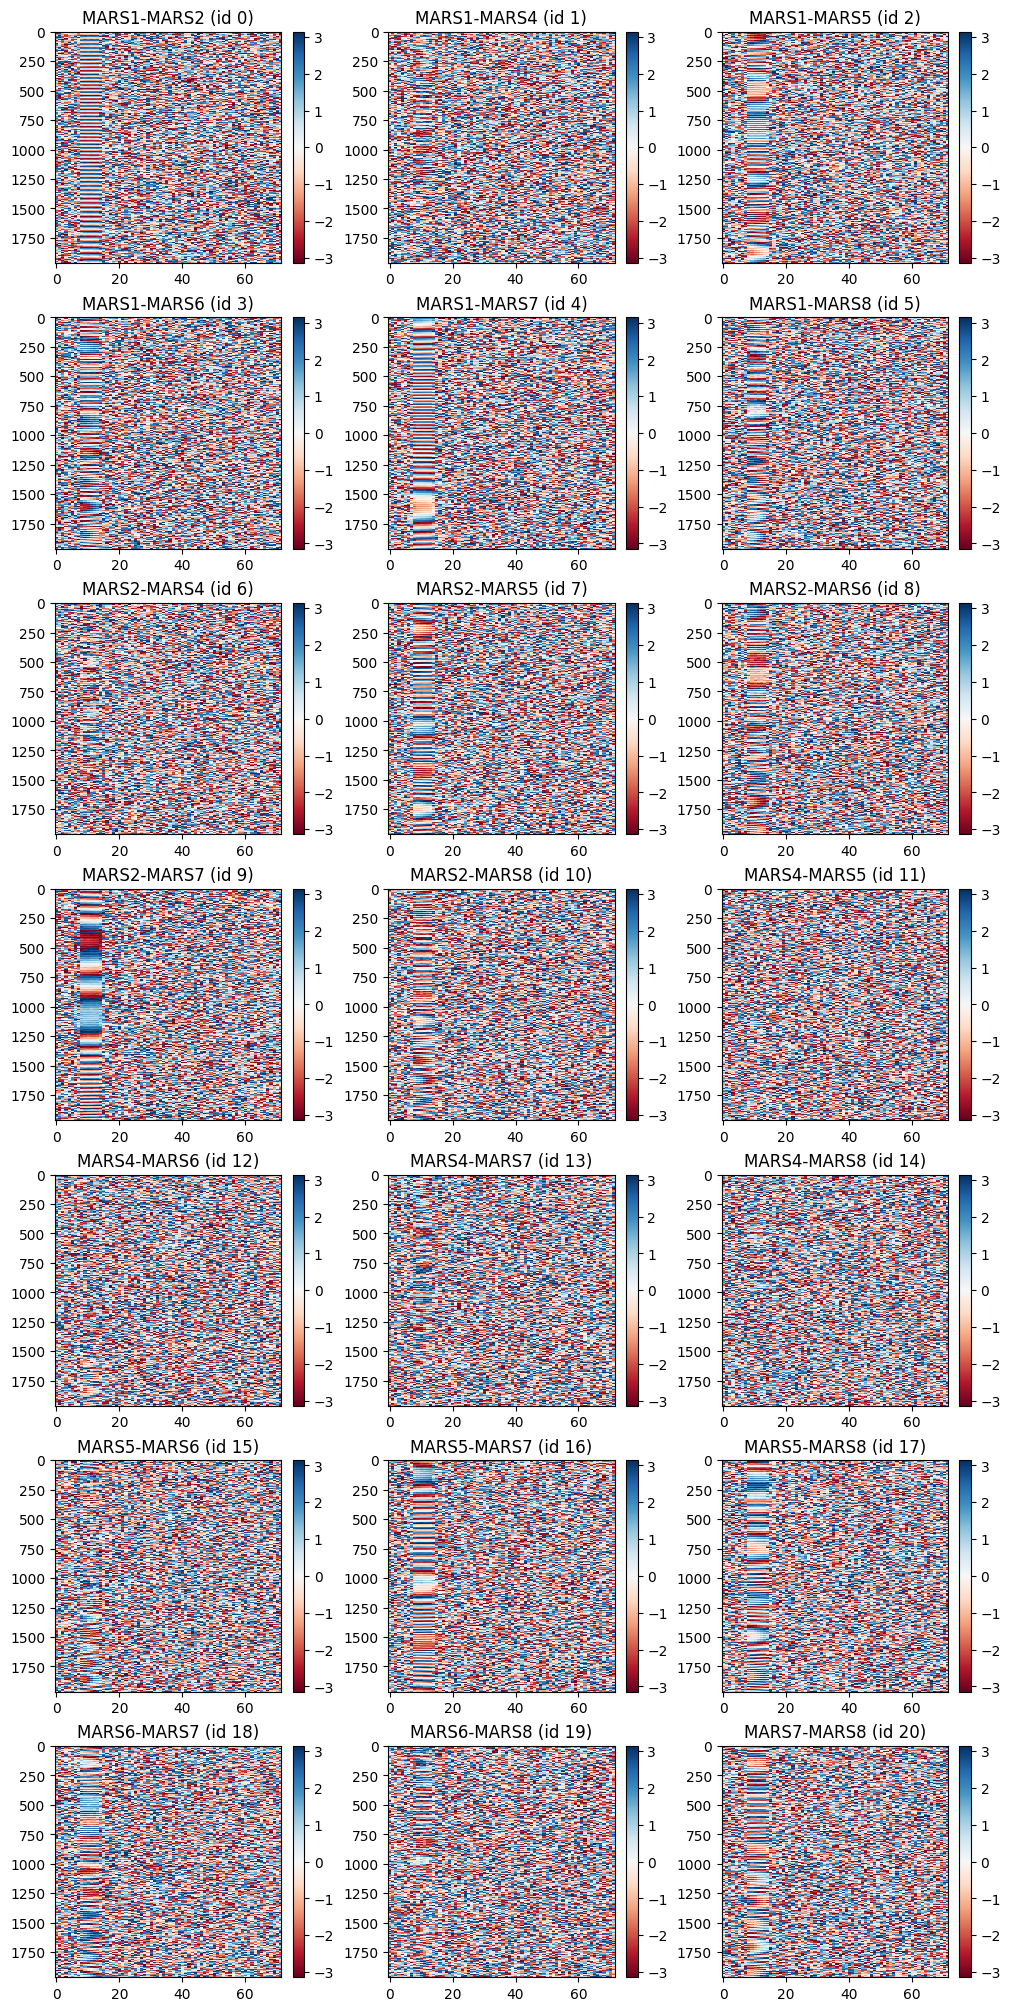

In [496]:
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(7,3, constrained_layout=True)
fig.set_size_inches(10,20)
ax=np.ravel(ax)

blnum=0
for i in range(len(antmap)):
        for j in range(i+1, len(antmap)):
            ax[blnum].set_title(f"{antmap[i]}-{antmap[j]} (id {blnum})")
            img=ax[blnum].imshow(np.angle(vis[:,:,blnum]),aspect='auto',interpolation='none',cmap='RdBu')
            cbar=plt.colorbar(img,ax=ax[blnum])
            blnum+=1

In [492]:
for blid in range(nbl):
    #sat = 59051
    sat = 57166
    ant1_idx, ant2_idx = triu_idx[0][blid], triu_idx[1][blid]
    name1, name2 = antmap[ant1_idx], antmap[ant2_idx]
    coord1, coord2 = coords[ant1_idx], coords[ant2_idx]
    print(ant1_idx, ant2_idx)
    print(name1, name2)

    chanid = 11
    freq = freqs[chanid]
    print('Frequency', freq / 1e6, 'MHz')

    # measured data
    angle_meas = np.angle(vis[:, chanid, blid])
    phase_meas = np.unwrap(angle_meas) - angle_meas[0]

    # predicted data
    niter = int(times[-1] - times[0]) + 2
    dt = times[1] - times[0]

    d = outils.get_sat_delay(coord1, coord2, tle_path, times[0], niter, sat)
    delays = np.interp(np.arange(0, ntimes) * dt, np.arange(0, niter), d)
    angle_pred = -2 * np.pi * freq * delays
    phase_pred = angle_pred - angle_pred[0]

    # residuals
    residuals = phase_meas - phase_pred

    # plot it
    fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(8, 6),sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # phase
    ax1.plot(times - times[0], phase_pred, label=f'Pred {sat}')
    ax1.plot(times - times[0], phase_meas, label='Data')
    ax1.set_ylabel('Phase (rads)')
    ax1.set_title(f'{name1}-{name2}')
    ax1.legend()

    # residuals
    ax2.plot(times - times[0], residuals)
    ax2.axhline(0, linestyle='--')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Residual (rad)')

    plt.tight_layout()
    path_plot = os.path.join(path_plots, f'{name1}_{name2}.png')
    fig.savefig(path_plot)
    plt.close(fig)

0 1
MARS1 MARS2
Frequency 137.8936767578125 MHz
catalog #57166 epoch 2025-07-23 14:49:57 UTC
one delay prediction: 0.08160662651062012
0 2
MARS1 MARS4
Frequency 137.8936767578125 MHz
catalog #57166 epoch 2025-07-23 14:49:57 UTC
one delay prediction: 0.0715179443359375
0 3
MARS1 MARS5
Frequency 137.8936767578125 MHz
catalog #57166 epoch 2025-07-23 14:49:57 UTC
one delay prediction: 0.07165312767028809


0 4
MARS1 MARS6
Frequency 137.8936767578125 MHz
catalog #57166 epoch 2025-07-23 14:49:57 UTC
one delay prediction: 0.07239246368408203
0 5
MARS1 MARS7
Frequency 137.8936767578125 MHz
catalog #57166 epoch 2025-07-23 14:49:57 UTC
one delay prediction: 0.07221269607543945
0 6
MARS1 MARS8
Frequency 137.8936767578125 MHz
catalog #57166 epoch 2025-07-23 14:49:57 UTC
one delay prediction: 0.07162857055664062
1 2
MARS2 MARS4
Frequency 137.8936767578125 MHz
catalog #57166 epoch 2025-07-23 14:49:57 UTC
one delay prediction: 0.07204461097717285
1 3
MARS2 MARS5
Frequency 137.8936767578125 MHz
catalog #57166 epoch 2025-07-23 14:49:57 UTC
one delay prediction: 0.07136678695678711
1 4
MARS2 MARS6
Frequency 137.8936767578125 MHz
catalog #57166 epoch 2025-07-23 14:49:57 UTC
one delay prediction: 0.07258939743041992
1 5
MARS2 MARS7
Frequency 137.8936767578125 MHz
catalog #57166 epoch 2025-07-23 14:49:57 UTC
one delay prediction: 0.07095909118652344
1 6
MARS2 MARS8
Frequency 137.8936767578125 MHz
catalog